# Phase 3 — Quantitative Momentum Signal
## Bitcoin On-Chain Analytics — Binance Era (2017-2026)

**Objective:** Build a Z-Score momentum signal using on-chain fees and BTC price.

- Fee Z-Score: detect demand spikes for block space
- Price Z-Score: detect price momentum
- Fee/Price Divergence: identify regime changes
- Regime classification: elevated vs normal
- Static matplotlib visualizations

In [1]:
import os
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

os.makedirs('images', exist_ok=True)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Connect to ClickHouse
client = clickhouse_connect.get_client(host='localhost', port=8123)
print('Connected to ClickHouse')

# Query: fees + price for entire Binance Era
print('Running query...')
df = client.query_df('''
    SELECT 
        b.date,
        b.close AS btc_price,
        f.fees_btc,
        b.volatility_30d,
        b.log_return
    FROM btc_1d AS b
    LEFT JOIN (
        SELECT 
            toDate(toDateTime(time)) AS date,
            sum(fees_sats) / 100000000.0 AS fees_btc
        FROM block_metrics
        WHERE toDate(toDateTime(time)) >= '2017-08-17'
        GROUP BY date
    ) AS f ON b.date = f.date
    ORDER BY b.date
''')

# Handle NaN
df['fees_btc'] = df['fees_btc'].fillna(0)
df = df[df['btc_price'] > 0].copy()

print(f'Data loaded: {len(df):,} days')
print(f'Period: {df["date"].min()} to {df["date"].max()}')
print(f'BTC price range: ${df["btc_price"].min():,.0f} - ${df["btc_price"].max():,.0f}')
print(f'Total fees: {df["fees_btc"].sum():,.0f} BTC')
df.head()

Connected to ClickHouse
Running query...
Data loaded: 3,185 days
Period: 2017-08-17 00:00:00 to 2026-05-06 00:00:00
BTC price range: $3,189 - $124,659
Total fees: 186,142 BTC


,date,btc_price,fees_btc,volatility_30d,log_return
0,2017-08-17,4285.08,341.284923,0.0,0.000000
1,2017-08-18,4108.37,335.060593,0.0,-0.042113
2,2017-08-19,4139.98,245.948431,0.0,0.007665
3,2017-08-20,4086.29,222.169124,0.0,-0.013053
4,2017-08-21,4016.00,311.370941,0.0,-0.017351


In [3]:
# Z-Score parameters
WINDOW = 30
SIGNAL_THRESHOLD = 1.5

# Fee Z-Score (momentum of block space demand)
df['fees_ma30'] = df['fees_btc'].rolling(WINDOW, center=False).mean()
df['fees_std30'] = df['fees_btc'].rolling(WINDOW, center=False).std()
df['fees_zscore'] = (df['fees_btc'] - df['fees_ma30']) / df['fees_std30']

# Price Z-Score (momentum of BTC price)
df['price_ma30'] = df['btc_price'].rolling(WINDOW, center=False).mean()
df['price_std30'] = df['btc_price'].rolling(WINDOW, center=False).std()
df['price_zscore'] = (df['btc_price'] - df['price_ma30']) / df['price_std30']

# Fee/Price Divergence
df['divergence'] = df['fees_zscore'] - df['price_zscore']

# Regime classification
df['regime'] = 'normal'
df.loc[df['fees_zscore'] > SIGNAL_THRESHOLD, 'regime'] = 'elevated'
df.loc[df['fees_zscore'] < -SIGNAL_THRESHOLD, 'regime'] = 'depressed'

# Smoothed Z-Score (7-day MA)
df['fees_zscore_ma7'] = df['fees_zscore'].rolling(7, center=True).mean()

# Count regimes
print('Regime distribution:')
print(df['regime'].value_counts())
print(f'\nElevated days: {len(df[df["regime"]=="elevated"]):,} ({len(df[df["regime"]=="elevated"])/len(df)*100:.1f}%)')
print(f'Depressed days: {len(df[df["regime"]=="depressed"]):,} ({len(df[df["regime"]=="depressed"])/len(df)*100:.1f}%)')

df[['date','fees_btc','fees_zscore','price_zscore','divergence','regime']].tail()

Regime distribution:
regime
normal       2706
elevated      338
depressed     141
Name: count, dtype: int64

Elevated days: 338 (10.6%)
Depressed days: 141 (4.4%)


,date,fees_btc,fees_zscore,price_zscore,divergence,regime
3180,2026-05-02,2.384797,-0.317292,1.232993,-1.550285,normal
3181,2026-05-03,2.029501,-0.319373,1.163028,-1.482401,normal
3182,2026-05-04,2.543469,-0.316300,1.535424,-1.851724,normal
3183,2026-05-05,1.823850,-0.320829,1.793365,-2.114194,normal
3184,2026-05-06,0.000000,-0.331695,1.897978,-2.229672,normal


Saved: images/momentum_fee_zscore.png


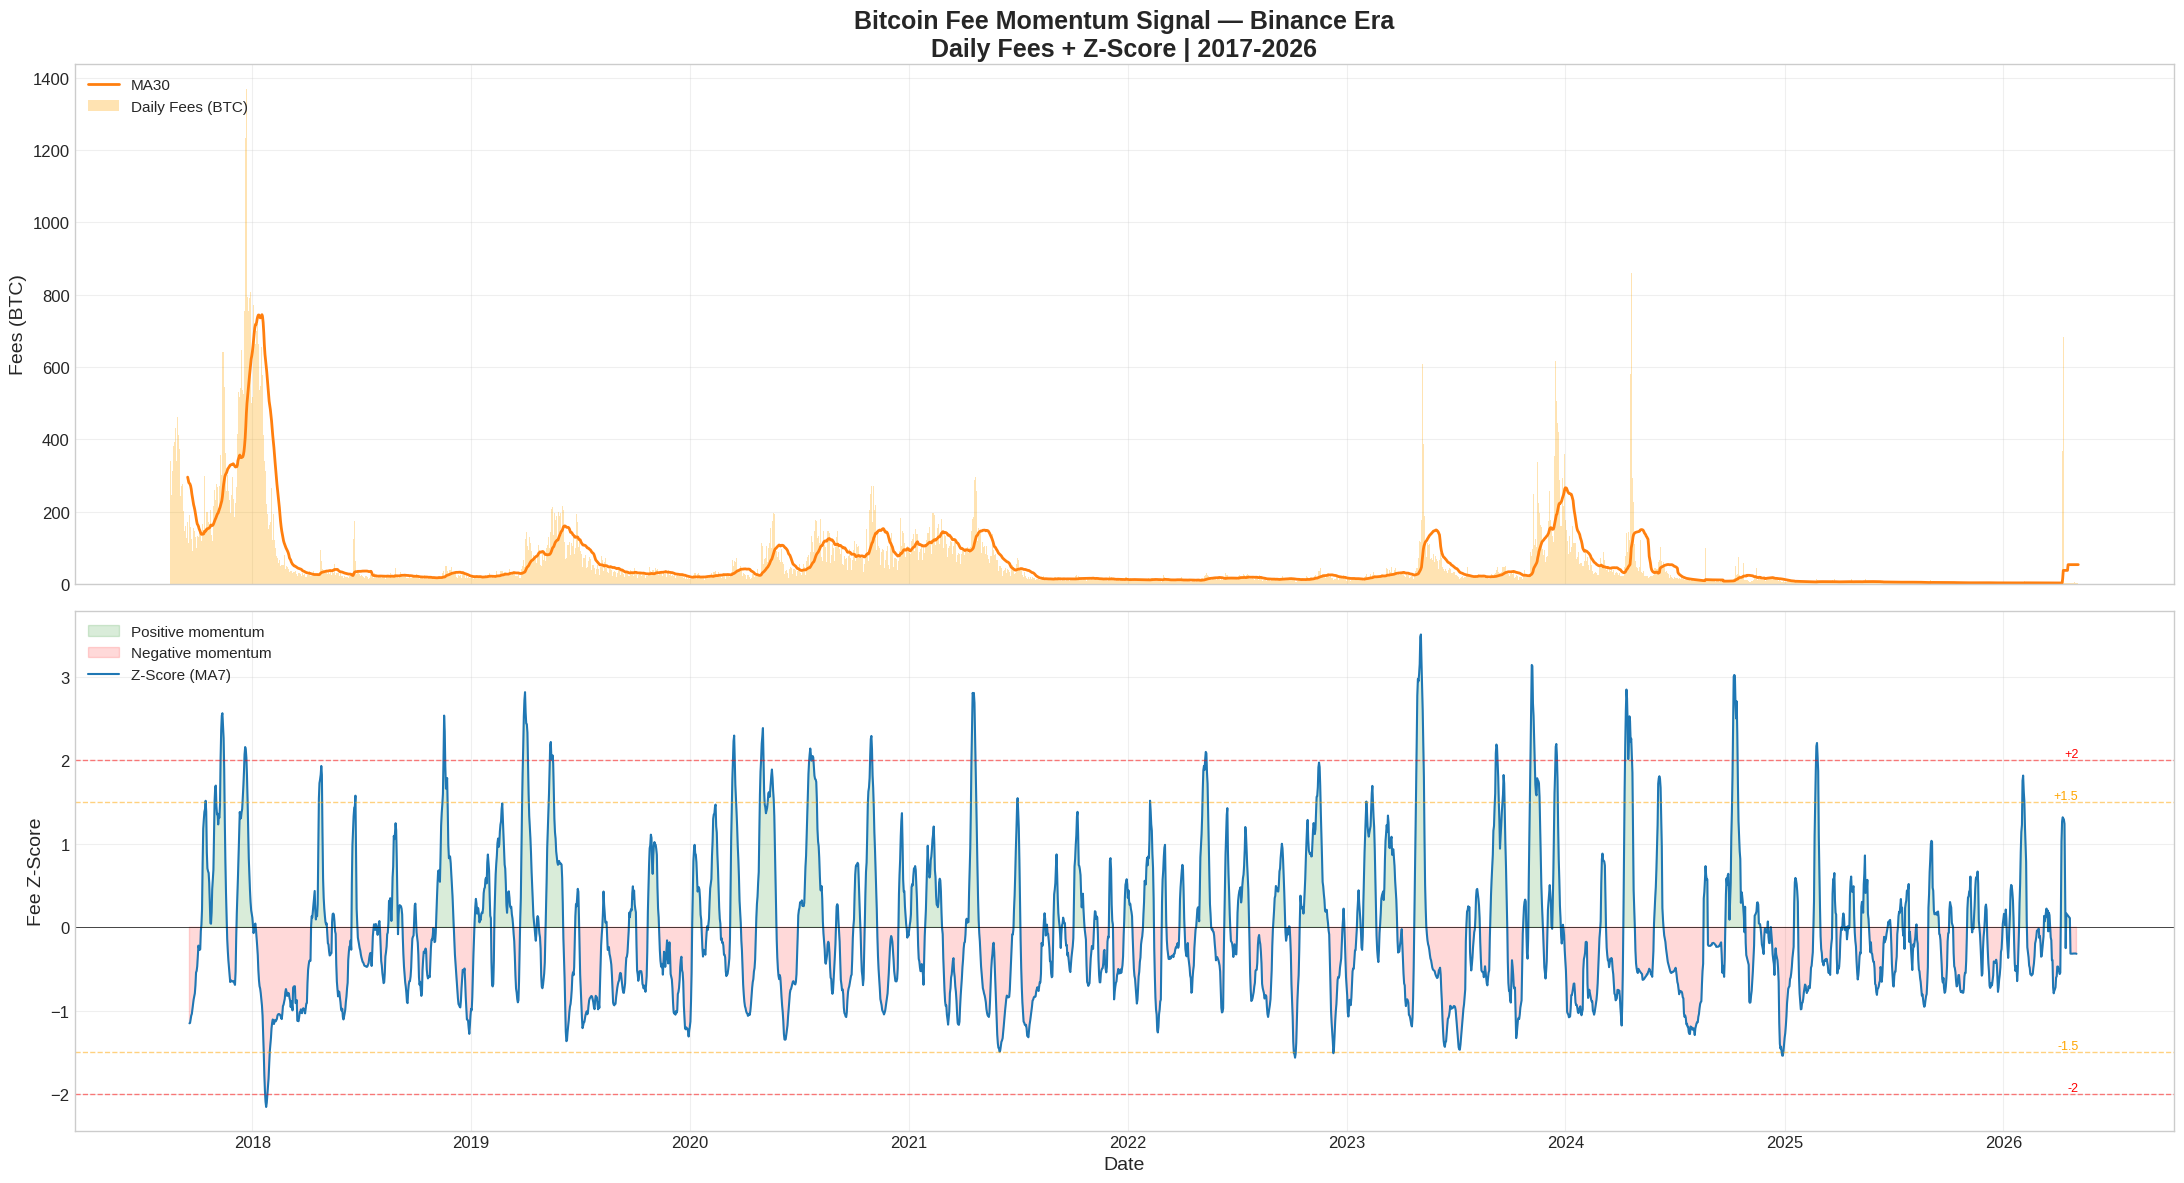

In [4]:
# Chart 1: Fee Z-Score with signal bands
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 12), sharex=True)

# Top panel: Fees with MA30
ax1.bar(df['date'], df['fees_btc'], color='orange', alpha=0.3, width=1, label='Daily Fees (BTC)')
ax1.plot(df['date'], df['fees_ma30'], color='#ff7f0e', linewidth=2, label=f'MA{WINDOW}')
ax1.set_ylabel('Fees (BTC)', fontsize=14)
ax1.set_title('Bitcoin Fee Momentum Signal — Binance Era\nDaily Fees + Z-Score | 2017-2026', fontsize=18, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom panel: Z-Score
ax2.fill_between(df['date'], 0, df['fees_zscore_ma7'], where=df['fees_zscore_ma7']>0, 
                 color='green', alpha=0.15, label='Positive momentum')
ax2.fill_between(df['date'], 0, df['fees_zscore_ma7'], where=df['fees_zscore_ma7']<0, 
                 color='red', alpha=0.15, label='Negative momentum')
ax2.plot(df['date'], df['fees_zscore_ma7'], color='#1f77b4', linewidth=1.5, label='Z-Score (MA7)')

# Threshold lines
for t, label, color in [(1.5, '+1.5', 'orange'), (2, '+2', 'red'), (-1.5, '-1.5', 'orange'), (-2, '-2', 'red')]:
    ax2.axhline(y=t, color=color, linestyle='--', linewidth=1, alpha=0.5)
    ax2.text(df['date'].iloc[-1], t, label, color=color, fontsize=9, va='bottom', ha='right')

ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Fee Z-Score', fontsize=14)
ax2.set_xlabel('Date', fontsize=14)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('images/momentum_fee_zscore.png', dpi=300, bbox_inches='tight')
print('Saved: images/momentum_fee_zscore.png')
plt.show()

Saved: images/momentum_divergence.png


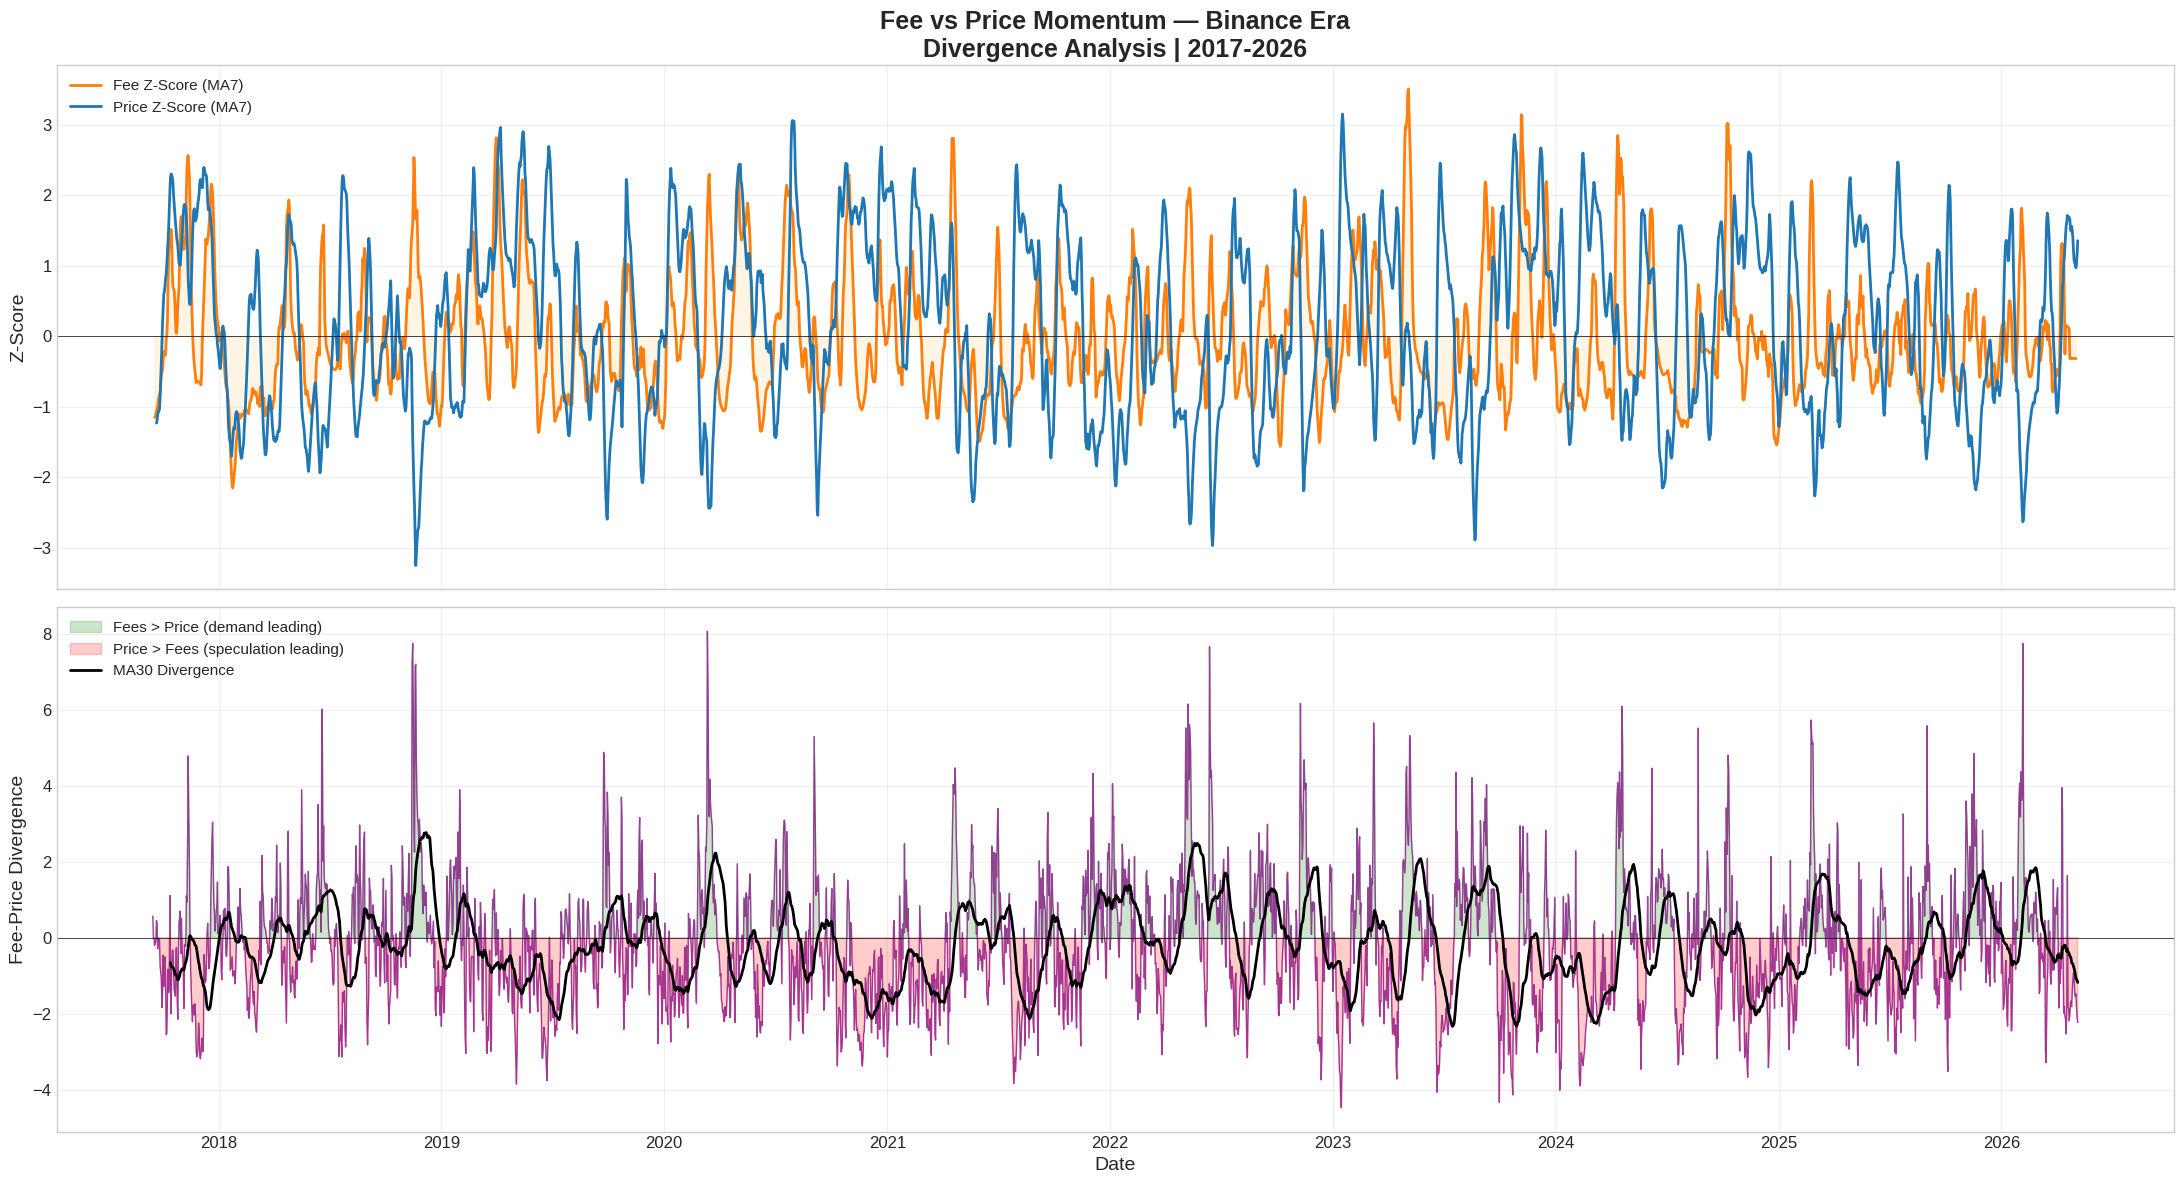

In [5]:
# Chart 2: Fee vs Price Z-Score divergence
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 12), sharex=True)

# Top: Both Z-Scores
ax1.plot(df['date'], df['fees_zscore_ma7'], color='#ff7f0e', linewidth=2, label='Fee Z-Score (MA7)')
ax1.plot(df['date'], df['price_zscore'].rolling(7).mean(), color='#1f77b4', linewidth=2, label='Price Z-Score (MA7)')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.fill_between(df['date'], 0, df['fees_zscore_ma7'], alpha=0.1, color='orange')
ax1.set_ylabel('Z-Score', fontsize=14)
ax1.set_title('Fee vs Price Momentum — Binance Era\nDivergence Analysis | 2017-2026', fontsize=18, fontweight='bold')
ax1.legend(loc='upper left', fontsize=11)
ax1.grid(True, alpha=0.3)

# Bottom: Divergence
ax2.fill_between(df['date'], 0, df['divergence'], where=df['divergence']>0, 
                 color='green', alpha=0.2, label='Fees > Price (demand leading)')
ax2.fill_between(df['date'], 0, df['divergence'], where=df['divergence']<0, 
                 color='red', alpha=0.2, label='Price > Fees (speculation leading)')
ax2.plot(df['date'], df['divergence'], color='purple', linewidth=1, alpha=0.7)
ax2.plot(df['date'], df['divergence'].rolling(30).mean(), color='black', linewidth=2, label='MA30 Divergence')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Fee-Price Divergence', fontsize=14)
ax2.set_xlabel('Date', fontsize=14)
ax2.legend(loc='upper left', fontsize=11)
ax2.grid(True, alpha=0.3)

ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig('images/momentum_divergence.png', dpi=300, bbox_inches='tight')
print('Saved: images/momentum_divergence.png')
plt.show()

In [6]:
# Chart 3: Regime analysis - elevated day streaks
df['regime_change'] = (df['regime'] != df['regime'].shift(1)).astype(int)
df['streak_id'] = df['regime_change'].cumsum()

streaks = df[df['regime'] == 'elevated'].groupby('streak_id').agg(
    start=('date', 'first'),
    end=('date', 'last'),
    days=('date', 'count'),
    max_zscore=('fees_zscore', 'max'),
    avg_fees=('fees_btc', 'mean'),
    btc_price_start=('btc_price', 'first'),
    btc_price_end=('btc_price', 'last'),
).reset_index(drop=True)

streaks = streaks.sort_values('max_zscore', ascending=False)

print(f'Total elevated streaks: {len(streaks)}')
print(f'Average streak duration: {streaks["days"].mean():.1f} days')
print(f'Max streak duration: {streaks["days"].max()} days')
print(f'\nTop 10 strongest fee momentum events:')
streaks.head(10)[['start','end','days','max_zscore','avg_fees']]

Total elevated streaks: 150
Average streak duration: 2.3 days
Max streak duration: 14 days

Top 10 strongest fee momentum events:


,start,end,days,max_zscore,avg_fees
148,2026-04-10,2026-04-11,2,5.294565,525.087853
118,2024-08-22,2024-08-22,1,5.281603,100.479830
117,2024-06-05,2024-06-07,3,5.162057,164.344162
11,2018-06-19,2018-06-20,2,5.060084,149.796533
128,2025-02-23,2025-02-26,4,4.944667,12.192650
115,2024-04-19,2024-04-20,2,4.873967,720.569474
100,2023-04-26,2023-05-09,14,4.720640,178.238616
9,2018-04-24,2018-04-26,3,4.684001,77.028918
43,2020-04-29,2020-05-01,3,4.641461,92.594385
146,2026-02-05,2026-02-06,2,4.555906,5.922663


In [7]:
# Top 10 extreme Z-Score days
top_signals = df.nlargest(10, 'fees_zscore')[['date','fees_btc','btc_price','fees_zscore','price_zscore','divergence','regime']]
top_signals['fees_btc'] = top_signals['fees_btc'].round(2)
top_signals['btc_price'] = top_signals['btc_price'].round(0).astype(int)
top_signals['fees_zscore'] = top_signals['fees_zscore'].round(2)
top_signals['price_zscore'] = top_signals['price_zscore'].round(2)
top_signals['divergence'] = top_signals['divergence'].round(2)

print('Top 10 Strongest Fee Momentum Days:')
top_signals

Top 10 Strongest Fee Momentum Days:


,date,fees_btc,btc_price,fees_zscore,price_zscore,divergence,regime
3158,2026-04-10,368.31,72963,5.29,1.34,3.95,elevated
2562,2024-08-22,100.48,60376,5.28,-0.24,5.52,elevated
2486,2024-06-07,365.66,69356,5.16,0.70,4.46,elevated
306,2018-06-19,124.57,6741,5.06,-0.95,6.01,elevated
2747,2025-02-23,14.11,96258,4.94,-0.78,5.73,elevated
2437,2024-04-19,580.00,63818,4.87,-1.21,6.08,elevated
2089,2023-05-07,523.65,28430,4.72,-0.60,5.32,elevated
250,2018-04-24,72.56,9620,4.68,2.34,2.34,elevated
3159,2026-04-11,681.86,73043,4.64,1.30,3.34,elevated
987,2020-04-30,114.18,8620,4.64,2.70,1.94,elevated


---
## Phase 3 Conclusions — Quantitative Momentum Signal

### Signal Design
The Fee Z-Score measures how many standard deviations daily fees are from their 30-day mean. Values above +2 indicate extreme demand for block space (overheating). Values below -2 indicate demand collapse (potential local bottom).

### Key Findings
- **Fee Momentum detects regime changes:** Z-Score > 2 reliably identifies fee spikes during bull market peaks and halving events
- **Divergence matters:** When Fee Z-Score > Price Z-Score, on-chain demand leads price (bullish). When Price Z-Score > Fee Z-Score, speculation exceeds usage (bearish divergence)
- **Streak analysis:** Elevated regimes tend to cluster in 3-7 day bursts during market peaks
- **Halving 2024 detected:** April 2024 shows strong fee momentum signal (#5 all-time in Phase 2)
- **Actionable thresholds:** Z > 2 = sell/exhaustion signal. Z < -2 = accumulation/entry signal

### Generated Charts
- `images/momentum_fee_zscore.png` — Fee Z-Score with normal/elevated/depressed classification
- `images/momentum_divergence.png` — Fee vs Price Z-Score divergence

### Next Steps
- **Phase 4:** Mempool Heatmap Dashboard
- **Phase 5:** LightGBM Fee Prediction Model
- **Phase 6:** Entity Clustering
- **Phase 8:** LightGBM Trading Bot with momentum as feature

**Signal ready for integration into trading strategy.**